In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
from src.problems import make_quadratic
from src.stopping_criterion import ExactConvexCertificate, ObservableConvexCertificate
from src.optimizer import minimize
from src.evaluation import plot_convergence

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
n_dim = 2
H = np.array([[4, 1], [1, 2]])
x_min = np.zeros(n_dim)
sigma = 0.5
R_domain = 10.0

problem = make_quadratic(H, sigma, center=x_min, R=R_domain)

In [10]:
# Hyperparameters
alpha = 0.05
eps = 1e-3  # Small for better profiling
eta0 = 0.2
gamma = 0.5
x0 = np.array([5.0, 5.0])

criterion = ExactConvexCertificate(x_min, sigma, alpha, eps)
# criterion = ObservableConvexCertificate(problem.R, sigma, alpha, eps)

Last Certificate: 0.477895
Last F_avg: 0.074888


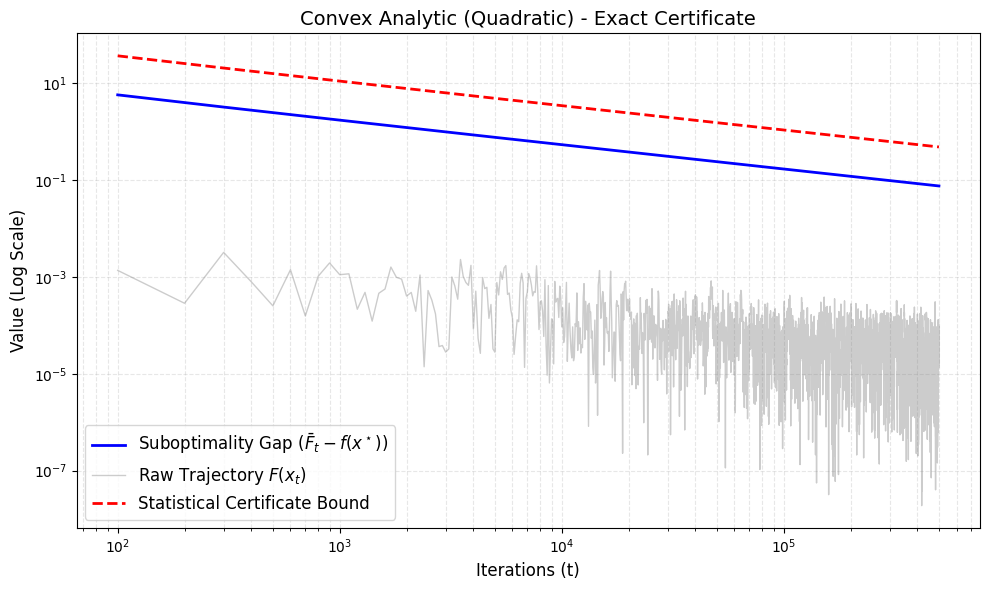

In [19]:
# Run and evaluation
report_interval=100
x_avg_t, results = minimize(
    fun=problem.fun,
    grad=problem.stoch_grad,
    proj=problem.proj,
    x0=x0,
    eta0=eta0,
    gamma=gamma,
    stopping_criterion=criterion,
    max_iter=500_000,
    verbose=False,       
    report_interval=report_interval, 
    true_grad=problem.true_grad
)

print(f"Last Certificate: {results['cert'][-1]:.6f}")
print(f"Last F_avg: {results['F_avg'][-1]:.6f}")

plot_convergence(results, bound_metric='F_avg', report_interval=report_interval, f_opt = 0.0, title="Convex Analytic (Quadratic) - Exact Certificate")